# Systems id photo

In [1]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import torchode

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

import torch
import torch.nn as nn
device='cpu'

from ftnode.utils import set_global_seed

seed = 1234
set_global_seed(seed = seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims = [2,20,20,20,2],
    lower_bound = -10,
    upper_bound =-0.1
)

g = GeluSigmoidMLP(
    dims = [6,20,20,20,2],
    lower_bound = -1,
    upper_bound = 8
)

model = FTNODE(f,g)

model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=2, bias=True)
    )
  )
)

In [3]:
def genetic_toggle_switch(state, t, alpha1, alpha2, beta, gamma):
    """
    Computes derivatives for Equation 27 (Li & Lin, 2013).
    """
    x1, x2 = state
    # Note: In this symmetric simulation, alpha1=alpha2 and beta=gamma
    dx1dt = -x1 + alpha1 / (1 + x2**beta)
    dx2dt = -x2 + alpha2 / (1 + x1**gamma)
    return [dx1dt, dx2dt]

In [4]:
seed = 1234
# set_global_seed(seed = seed)

n_cases = 16
rng = np.random.default_rng(seed)

# idxs = rng.choice(len(dataset), size=n_cases, replace=False)

x1s = rng.uniform(low=0.0, high=6.0, size=n_cases)
x2s = rng.uniform(low=0.0, high=6.0, size=n_cases)

a1s = rng.uniform(low=0.0, high=5.0, size=n_cases)
a2s = rng.uniform(low=0.0, high=5.0, size=n_cases)

betas = rng.uniform(low=0.0, high=5.0, size=n_cases)
gammas = rng.uniform(low=0.0, high=5.0, size=n_cases)

X0s = np.vstack((x1s,x2s)).T
Us = np.vstack((a1s,a2s,betas,gammas)).T

XU = [(x0i,ui) for x0i, ui in zip(X0s,Us)]


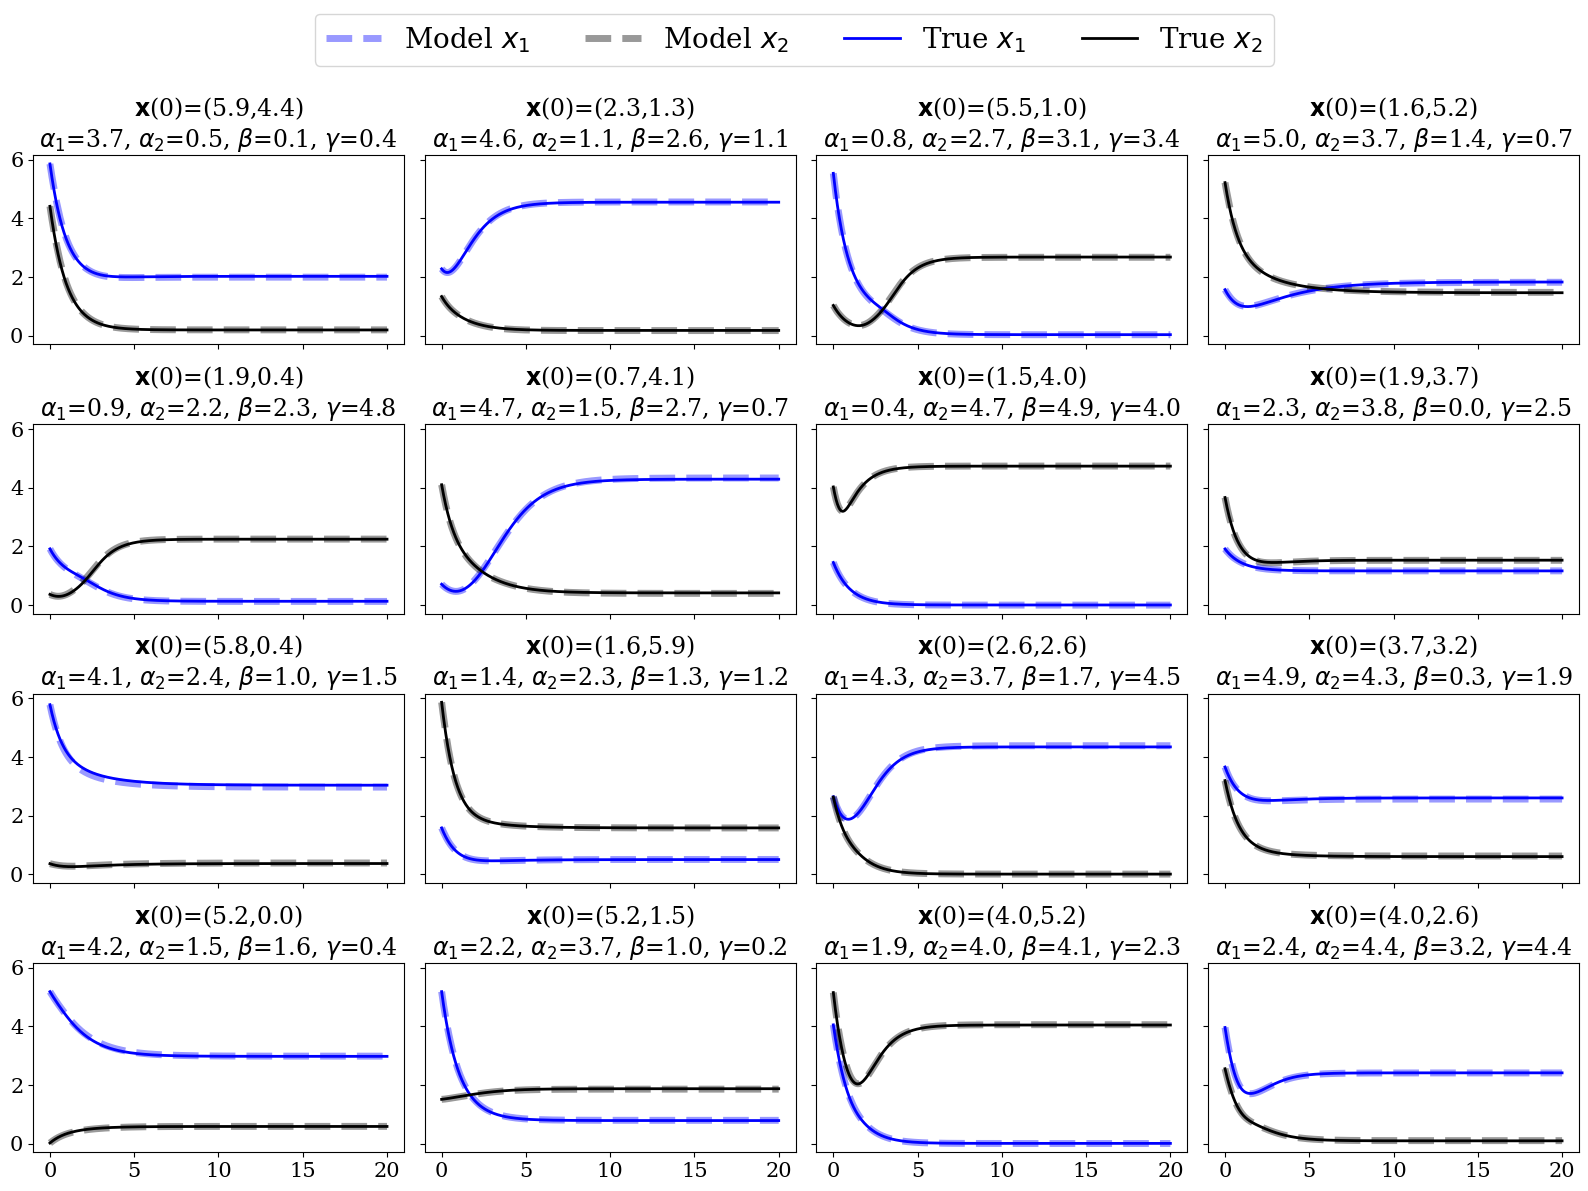

In [5]:
t_sim_max = 20


fig, axes = plt.subplots(4, 4, figsize=(16, 12),sharey=True, sharex=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):

    x0i, ui = XU[idx]

    ui_torch = torch.tensor(ui,dtype=torch.float32)
    x0i = torch.tensor(x0i,dtype=torch.float32).reshape(1, -1)

    with torch.no_grad():
        control = lambda t: ui_torch
        ti = torch.linspace(0, t_sim_max, 501, dtype=torch.float32)
        func = lambda t, x: model(t, x, control)

        sol_model = torchode.solve_ivp(
            f=func,
            y0=x0i,
            t_eval=ti,
            method='tsit5'
        )

    y_true = odeint(
        genetic_toggle_switch,
        x0i.numpy()[0],
        ti.numpy(),
        args=tuple(ui)
    )


    y_pred = sol_model.ys[0]

    ax.plot(ti, y_pred[:, 0], lw=5, alpha=0.4, linestyle='--', label=r"Model $x_1$", c='blue')
    ax.plot(ti, y_pred[:, 1], lw=5, alpha=0.4, linestyle='--', label=r"Model $x_2$", c='black')

    ax.plot(ti, y_true[:, 0], lw=2, c='blue', label=r"True $x_1$")
    ax.plot(ti, y_true[:, 1], lw=2, c='black', label=r"True $x_2$")

    
    x0 = x0i.numpy().flatten()
    ax.set_title(
        r"$\bf{x}$(0)="+f"({x0[0]:.1f},{x0[1]:.1f})"+"\n"
        rf"$\alpha_1$={ui[0]:.1f}, $\alpha_2$={ui[1]:.1f}, "
        rf"$\beta$={ui[2]:.1f}, $\gamma$={ui[3]:.1f}",
        fontsize=17
    )


for ax in axes.flatten():
    ax.tick_params(axis='both', which='major',labelsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4,fontsize=20)


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("toggle-traj.png")
plt.show()